# Detector-level 2 m SCAO

**Scientific question.** What short-run correction does the shared
`shwfs_ao.control.run_closed_loop` engine deliver for a 2 m telescope with
physical v2 turbulence and photon/read noise enabled?

This uses the same loop implementation as `high_order_scao.ipynb`, under
different aperture, atmosphere, sampling, and control parameters. Comparing
those notebooks does not isolate a noise contribution.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
    SPECTRUM_SUBHARMONIC_V2,
    TRANSLATION_FOURIER_SUBPIXEL_V2,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 2.0
WFS_WAVELENGTH_M = 700e-9
SCIENCE_WAVELENGTH_M = 1.65e-6
PUPIL_PIXELS = 96 if FAST_SMOKE else 120
N_LENSLETS_ACROSS = 8 if FAST_SMOKE else 10
N_ACTUATORS_ACROSS = 7 if FAST_SMOKE else 9
N_STEPS = 6 if FAST_SMOKE else 16

## Configuration

In [4]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(PUPIL_PIXELS, PUPIL_PIXELS),
    n_lenslets_across=N_LENSLETS_ACROSS,
    min_fill_fraction=0.4,
)
pupil = geometry.pupil_geometry
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=3e4, read_noise_e=2.0),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=N_ACTUATORS_ACROSS,
        coupling_width_pitch=0.35,  # Synthetic narrow Gaussian basis (~1.7% coupling).
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=30e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
atmosphere = FrozenFlowAtmosphere(
    FrozenFlowAtmosphereConfig(
        grid_size=geometry.pupil_shape[0],
        screen_grid_size=3 * geometry.pupil_shape[0],
        spectrum_model=SPECTRUM_SUBHARMONIC_V2,
        translation_model=TRANSLATION_FOURIER_SUBPIXEL_V2,
        normalize_rms=False,
        delta_m=pupil.pixel_spacing_xy_m[0],
        pupil_diameter_m=TELESCOPE_DIAMETER_M,
        r0_m=0.18,
        outer_scale_m=25.0,
        wind_m_per_s=(9.0, 0.0),
        root_seed=SEED,
    ),
    pupil_mask=geometry.pupil_mask,
)
print(f"D/r0 = {TELESCOPE_DIAMETER_M / 0.18:.1f}; {int(mirror.n_actuators)} active actuators")


D/r0 = 11.1; 49 active actuators


## Simulation call

In [5]:
history = run_closed_loop(
    LoopConfig(
        n_steps=N_STEPS,
        gain=0.4,
        leak=0.01,
        latency_frames=1,
        frame_rate_hz=1000.0,
        root_seed=SEED,
    ),
    random_streams=NamedRandomStreams(SEED),
    atmosphere=atmosphere,
    wfs=sensor,
    dm=mirror,
    interaction_matrix=interaction,
    reconstructor=LeastSquaresReconstructor(
        interaction, min_valid_fraction=0.5, min_rank=1
    ),
    command_projector=IdentityCommandProjector(mirror.actuator_ids),
    controller=LeakyIntegratorController(
        mirror.actuator_ids, gain=0.4, leak=0.01, latency_frames=1
    ),
    include_noise=True,
    realization_index=0,
)
open_loop = np.asarray(history.open_loop_opd_rms_m, dtype=float)
closed_loop = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)
settled = float(np.mean(closed_loop[N_STEPS // 2:]))
strehl = float(np.exp(-((2 * np.pi * settled / SCIENCE_WAVELENGTH_M) ** 2)))
open_settled = float(np.mean(open_loop[N_STEPS // 2:]))
assert np.all(np.isfinite(open_loop)) and np.all(np.isfinite(closed_loop))
assert settled >= 0 and open_settled > 0 and 0 < strehl <= 1


## Diagnostic table

In [6]:
table = pd.DataFrame(
    [
        ("Telescope diameter", TELESCOPE_DIAMETER_M, "m"),
        ("Open-loop RMS (final half)", open_settled * 1e9, "nm"),
        ("Closed-loop RMS (final half)", settled * 1e9, "nm"),
        ("Residual fraction", settled / open_settled, "-"),
        ("H-band Maréchal estimate (RMS includes tilt)", strehl, "-"),
        ("Loop engine", history.metadata["backend_names"]["dm"], ""),
        ("Noise included", True, ""),
    ],
    columns=["quantity", "value", "units"],
)
table

,quantity,value,units
0,Telescope diameter,2.0,m
1,Open-loop RMS (final half),394.230408,nm
2,Closed-loop RMS (final half),354.987763,nm
3,Residual fraction,0.900458,-
4,H-band Maréchal estimate (RMS includes tilt),0.160841,-
5,Loop engine,native,
6,Noise included,True,


## Plot

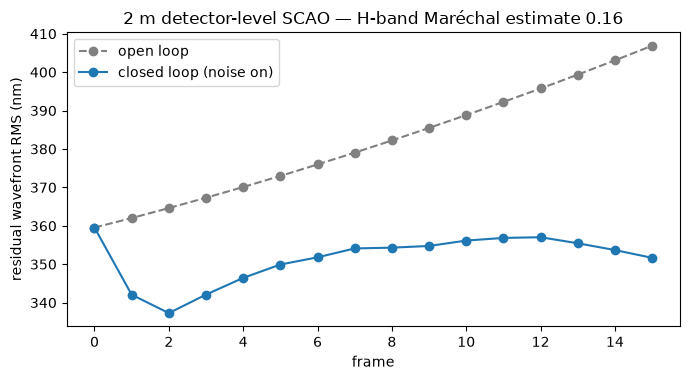

In [7]:
frames = np.arange(N_STEPS)
figure, axis = plt.subplots(figsize=(7.0, 3.9))
axis.plot(frames, open_loop * 1e9, "o--", color="0.5", label="open loop")
axis.plot(frames, closed_loop * 1e9, "o-", color="C0", label="closed loop (noise on)")
axis.set_xlabel("frame")
axis.set_ylabel("residual wavefront RMS (nm)")
axis.set_title(f"2 m detector-level SCAO — H-band Maréchal estimate {strehl:.2f}")
axis.legend()
figure.tight_layout()
plt.show()

## Interpretation

The trace and matched final-half means describe one short run with photon and
read noise enabled. The residual combines the physical disturbance, the
synthetic mirror basis, sensing and reconstruction, noise, and temporal
control. Gaussian influence width `0.35 × pitch` means about **1.7% neighbour
coupling**; this deliberately narrow basis is not a calibrated real mirror.

The higher-order notebook shares the loop engine, but it changes aperture,
`r0`, wind, sampling, gain, leak, noise, and realization. Their output difference
cannot be assigned to photon/read noise or fitting error alone. A measured
noise penalty would require a paired noise-on/noise-off run with those other
quantities held fixed.

## Limitations

- Sixteen frames and one seed do not establish a steady-state error budget or
  general stability. Performance estimates require longer, repeated runs.
- The reported H-band value is a small-error Maréchal estimate from RMS that
  includes tip/tilt, not a propagated peak-PSF Strehl.
- Photon and read-noise settings are illustrative and not tied to a specific
  instrument or guide-star magnitude.
